# Constructing an LBO Model in Python: From Capital Structure Theory to Transaction Returns

This notebook translates the classroom LBO drill logic from Excel into a structured Python workflow. The goal is not to replicate every spreadsheet tab, but to preserve the core deal logic in a cleaner, auditable modeling sequence.

## Learning objectives

By the end of this notebook, you should be able to:

- connect capital structure theory to LBO transaction mechanics,
- build a drill-style Sources & Uses and financing stack,
- model operating cash flow and debt deleveraging,
- evaluate lender-style credit metrics,
- compute sponsor MOIC and IRR clearly,
- stress-test outcomes with sensitivity analysis.

## Why this notebook matters

In class, you reviewed an Excel LBO drill. Here we keep the same economic logic and terminology while translating it into a reproducible Python model suitable for discussion and scenario analysis.


## 1. Where this notebook fits in the course

Earlier sessions introduced capital structure, tax shields, governance discipline, and leverage risk. This notebook applies those ideas to a leveraged acquisition case using recognizable drill components: premium and dilution logic, Sources & Uses, credit metrics, equity returns, and compact goodwill intuition. The next notebook moves to market-level strategy design and backtesting.


## 2. Theoretical framing: why leverage matters in LBOs

A compact theoretical lens helps interpret model outputs:

- **Modigliani-Miller with taxes:** debt can create value through the interest tax shield.
- **Trade-Off Theory:** leverage can improve value up to the point where distress risk and financing frictions become too costly.
- **Pecking Order Theory:** internal funds are preferred, then debt, then new equity; LBOs typically maximize debt capacity before sponsor equity.
- **Agency Theory and debt discipline:** leverage increases performance pressure and monitoring intensity, which can reduce managerial slack.

**In an LBO, leverage is not just a financing choice; it is part of the value-creation logic and governance discipline of the transaction.**


## 3. Model architecture overview

Financial question: how do we go from assumptions to equity returns in a sequence that is easy to audit?

Why it matters: LBO outputs are only useful if the path from inputs to outputs is explicit.

Link: after the theoretical framing, we now build a practical transaction roadmap:

Inputs
-> Entry valuation and Sources & Uses
-> Premium and dilution bridge
-> Financing layers
-> Operating projections
-> Debt schedule and deleveraging
-> Credit monitoring
-> Exit valuation and equity returns
-> Sensitivity analysis


### Code setup

We load only the core libraries used throughout this repository.


In [22]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import numpy_financial as npf
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
pd.set_option("display.float_format", "{:.2f}".format)


## 4. Transaction setup and Sources & Uses

**Financial question:** How is the deal funded at entry, and does the transaction balance->

This matters because Sources & Uses is the transaction anchor: it defines purchase economics, financing needs, and sponsor equity check before any projection is run.


### Define core transaction assumptions

The assumptions are organized to mirror drill-style modeling blocks (valuation, premium/dilution, financing mix, operations, and exit). This keeps the notebook close to the classroom case while remaining concise.


In [23]:
assumptions = {
    # Entry valuation
    "entry_ebitda": 830.0,              # USDm
    "entry_multiple": 7.0,              # EV / EBITDA
    "existing_net_debt": 297.0,         # USDm refinanced at close
    "transaction_fee_pct": 0.0065,      # advisory fees as % of EV

    # Premium / dilution bridge
    "current_share_price": 5.50,
    "basic_shares_m": 812.0,
    "option_strikes": [0.00, 1.82, 3.50, 5.00],
    "option_counts_m": [4.16, 8.84, 12.50, 10.10],

    # Financing assumptions (drill-style stack)
    "pct_term_debt_a": 0.35,
    "pct_term_debt_b": 0.15,
    "pct_term_debt_c": 0.10,
    "pct_high_yield_bond": 0.10,
    "rate_term_debt_a": 0.060,
    "rate_term_debt_b": 0.070,
    "rate_term_debt_c": 0.080,
    "rate_high_yield_bond": 0.105,
    "mandatory_amort_tda_pct": 0.10,    # of initial TDA per year
    "mandatory_amort_tdb_pct": 0.03,    # of initial TDB per year
    "mandatory_amort_tdc_pct": 0.00,
    "cash_sweep_pct": 0.75,

    # Operating assumptions
    "holding_period_years": 5,
    "tax_rate": 0.25,
    "revenue_growth": 0.055,
    "ebitda_margin": 0.20,
    "depreciation_pct_revenue": 0.025,
    "capex_pct_revenue": 0.035,
    "nwc_pct_revenue": 0.020,

    # Net debt convention
    "cash_on_balance_sheet": 16.8,
    "exit_multiple": 7.5,
}

assumptions_df = pd.DataFrame.from_dict(assumptions, orient="index", columns=["Value"])
assumptions_df


,Value
entry_ebitda,830.00
entry_multiple,7.00
existing_net_debt,297.00
transaction_fee_pct,0.01
current_share_price,5.50
basic_shares_m,812.00
option_strikes,"[0.0, 1.82, 3.5, 5.0]"
option_counts_m,"[4.16, 8.84, 12.5, 10.1]"
pct_term_debt_a,0.35
pct_term_debt_b,0.15


### Build Sources & Uses schedule

We keep the labels close to the drill: Acquisition cost, Refinanced debt, Advisory fees, and financing from Term debt A/B/C, High Yield Bond, and New equity.


In [24]:
entry_ev = assumptions["entry_ebitda"] * assumptions["entry_multiple"]
equity_purchase_value = entry_ev - assumptions["existing_net_debt"]

# Premium / dilution mechanics (treasury-style simplification)
implied_share_price_basic = equity_purchase_value / assumptions["basic_shares_m"]
option_dilution = pd.DataFrame({
    "OptionStrike": assumptions["option_strikes"],
    "OptionCount_m": assumptions["option_counts_m"],
})
option_dilution["NetNewShares_m"] = np.maximum(
    (implied_share_price_basic - option_dilution["OptionStrike"]) / implied_share_price_basic * option_dilution["OptionCount_m"],
    0.0,
)
diluted_shares_m = assumptions["basic_shares_m"] + option_dilution["NetNewShares_m"].sum()
implied_share_price_diluted = equity_purchase_value / diluted_shares_m
implied_premium_pct = implied_share_price_diluted / assumptions["current_share_price"] - 1

acquisition_cost = implied_share_price_diluted * diluted_shares_m
fees = entry_ev * assumptions["transaction_fee_pct"]
uses_total = acquisition_cost + assumptions["existing_net_debt"] + fees

debt_tranches = pd.DataFrame([
    {"Tranche": "Term debt A", "PctOfUses": assumptions["pct_term_debt_a"], "InterestRate": assumptions["rate_term_debt_a"], "Seniority": "Senior"},
    {"Tranche": "Term debt B", "PctOfUses": assumptions["pct_term_debt_b"], "InterestRate": assumptions["rate_term_debt_b"], "Seniority": "Senior"},
    {"Tranche": "Term debt C", "PctOfUses": assumptions["pct_term_debt_c"], "InterestRate": assumptions["rate_term_debt_c"], "Seniority": "Senior"},
    {"Tranche": "High Yield Bond", "PctOfUses": assumptions["pct_high_yield_bond"], "InterestRate": assumptions["rate_high_yield_bond"], "Seniority": "Subordinated"},
])
debt_tranches["Amount"] = uses_total * debt_tranches["PctOfUses"]

debt_total = debt_tranches["Amount"].sum()
sponsor_equity = uses_total - debt_total

sources_uses = pd.DataFrame({
    "Uses": [
        "Acquisition cost",
        "Refinanced debt",
        "Advisory fees",
        "Total Uses",
    ],
    "Uses (USDm)": [
        acquisition_cost,
        assumptions["existing_net_debt"],
        fees,
        uses_total,
    ],
    "Sources": [
        "Debt financing",
        "New equity",
        "Total Sources",
        "Balancing Check (Sources - Uses)",
    ],
    "Sources (USDm)": [
        debt_total,
        sponsor_equity,
        debt_total + sponsor_equity,
        debt_total + sponsor_equity - uses_total,
    ],
})

sources_uses


,Uses,Uses (USDm),Sources,Sources (USDm)
0,Acquisition cost,5513.00,Debt financing,4093.44
1,Refinanced debt,297.00,New equity,1754.33
2,Advisory fees,37.77,Total Sources,5847.77
3,Total Uses,5847.77,Balancing Check (Sources - Uses),0.00


### Interpretation

A balanced Sources & Uses confirms that transaction funding is internally consistent. Sponsor equity becomes the residual funding item after debt capacity is set.


## 5. Takeover valuation and premium logic

Financial question: what premium does the transaction imply once dilution is recognized?

Why it matters: premium and diluted share count are central to acquisition economics and sponsor entry discipline.

Link: Sources & Uses defined total uses; now we validate equity purchase logic in drill-style terms.


### Build premium and dilution bridge

The bridge uses a simplified treasury-stock approach for options to stay close to classroom drill mechanics without overcomplicating implementation.


In [25]:
premium_table = pd.DataFrame({
    "Metric": [
        "Current Share Price (USD)",
        "Basic Shares Outstanding (m)",
        "Implied Share Price (basic)",
        "Net New Shares from Options (m)",
        "Diluted Shares Outstanding (m)",
        "Implied Share Price (diluted)",
        "Implied Premium to Current Share Price",
    ],
    "Value": [
        assumptions["current_share_price"],
        assumptions["basic_shares_m"],
        implied_share_price_basic,
        option_dilution["NetNewShares_m"].sum(),
        diluted_shares_m,
        implied_share_price_diluted,
        implied_premium_pct,
    ],
})

option_dilution, premium_table


(   OptionStrike  OptionCount_m  NetNewShares_m
 0          0.00           4.16            4.16
 1          1.82           8.84            6.47
 2          3.50          12.50            6.06
 3          5.00          10.10            2.66,
                                    Metric  Value
 0               Current Share Price (USD)   5.50
 1            Basic Shares Outstanding (m) 812.00
 2             Implied Share Price (basic)   6.79
 3         Net New Shares from Options (m)  19.35
 4          Diluted Shares Outstanding (m) 831.35
 5           Implied Share Price (diluted)   6.63
 6  Implied Premium to Current Share Price   0.21)

### Interpretation

Premium analysis helps students reconcile headline offer terms with implied equity check size. In full deal models, dilution logic is richer; here it is intentionally simplified for classroom use.


## 6. Capital structure and financing layers

Financial question: why split debt across financing layers instead of using one instrument?

Why it matters: tranche design affects pricing, amortization profile, covenant pressure, and refinancing risk.

Link: premium and purchase economics define funding needs; this section formalizes how those needs are funded.


### Present financing stack

This stack intentionally mirrors common drill language: Term debt A, Term debt B, Term debt C, High Yield Bond, and New equity.


In [26]:
capital_structure = debt_tranches.copy()
capital_structure["Type"] = "Debt"
capital_structure["Comment"] = [
    "Core senior tranche with stronger amortization discipline.",
    "Senior tranche with lighter amortization and larger institutional placement.",
    "Additional senior capacity, often used to optimize funding mix.",
    "Higher-cost subordinated layer providing leverage flexibility.",
]

equity_row = pd.DataFrame([
    {
        "Tranche": "New equity",
        "Amount": sponsor_equity,
        "PctOfUses": 1 - debt_tranches["PctOfUses"].sum(),
        "InterestRate": np.nan,
        "Seniority": "Residual Claim",
        "Type": "Equity",
        "Comment": "First-loss capital; captures upside after debt service.",
    }
])

capital_structure = pd.concat([capital_structure, equity_row], ignore_index=True)
capital_structure_display = capital_structure[["Tranche", "Type", "Amount", "PctOfUses", "InterestRate", "Seniority", "Comment"]].copy()
capital_structure_display["InterestRate"] = capital_structure_display["InterestRate"].map(lambda x: "-" if pd.isna(x) else f"{x:.1%}")
capital_structure_display


,Tranche,Type,Amount,PctOfUses,InterestRate,Seniority,Comment
0,Term debt A,Debt,2046.72,0.35,6.0%,Senior,Core senior tranche with stronger amortization...
1,Term debt B,Debt,877.16,0.15,7.0%,Senior,Senior tranche with lighter amortization and l...
2,Term debt C,Debt,584.78,0.10,8.0%,Senior,"Additional senior capacity, often used to opti..."
3,High Yield Bond,Debt,584.78,0.10,10.5%,Subordinated,Higher-cost subordinated layer providing lever...
4,New equity,Equity,1754.33,0.30,-,Residual Claim,First-loss capital; captures upside after debt...


### Interpretation

Layering debt allows the transaction to combine lower-cost senior debt with higher-cost junior financing where needed. The structure reflects trade-offs between leverage, flexibility, and risk.


### Visual check of initial capital structure

A simple composition chart helps communicate who funds the transaction at entry.


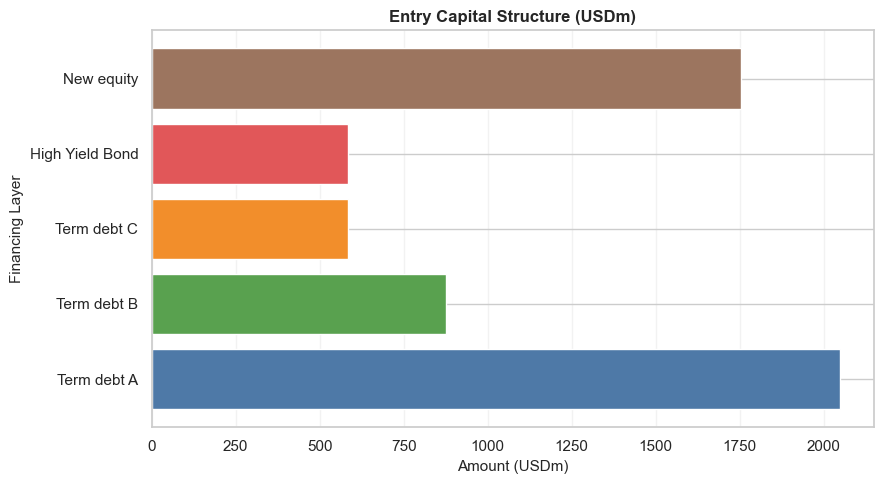

In [27]:
plot_df = capital_structure.copy()
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_df["Tranche"], plot_df["Amount"], color=["#4e79a7", "#59a14f", "#f28e2b", "#e15759", "#9c755f"])
ax.set_title("Entry Capital Structure (USDm)")
ax.set_xlabel("Amount (USDm)")
ax.set_ylabel("Financing Layer")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()


## 7. Operating model

Financial question: can projected operations generate enough recurring cash flow to support the leveraged structure?

Why it matters: LBO feasibility is a cash-flow question, not only a valuation question.

Link: once financing is set, we test whether business performance can service and reduce debt.


### Project operations and free cash flow available for debt service

Formulas remain intentionally transparent and close to spreadsheet logic.


In [28]:
years = np.arange(1, assumptions["holding_period_years"] + 1)

entry_revenue = assumptions["entry_ebitda"] / assumptions["ebitda_margin"]
revenue = [entry_revenue * (1 + assumptions["revenue_growth"]) ** y for y in years]
ebitda = [r * assumptions["ebitda_margin"] for r in revenue]
depreciation = [r * assumptions["depreciation_pct_revenue"] for r in revenue]
ebit = [e - d for e, d in zip(ebitda, depreciation)]
taxes = [max(x, 0) * assumptions["tax_rate"] for x in ebit]
capex = [r * assumptions["capex_pct_revenue"] for r in revenue]

nwc = [r * assumptions["nwc_pct_revenue"] for r in revenue]
change_nwc = [nwc[0]] + [nwc[i] - nwc[i - 1] for i in range(1, len(nwc))]

fcf_pre_interest = [
    op_ebit - tax + dep - cpx - d_nwc
    for op_ebit, tax, dep, cpx, d_nwc in zip(ebit, taxes, depreciation, capex, change_nwc)
]

operating_model = pd.DataFrame({
    "Year": years,
    "Revenue": revenue,
    "EBITDA": ebitda,
    "Depreciation": depreciation,
    "EBIT": ebit,
    "Taxes": taxes,
    "Capex": capex,
    "ChangeNWC": change_nwc,
    "FCF_PreInterest": fcf_pre_interest,
})

operating_model


,Year,Revenue,EBITDA,Depreciation,EBIT,Taxes,Capex,ChangeNWC,FCF_PreInterest
0,1,4378.25,875.65,109.46,766.19,191.55,153.24,87.56,443.30
1,2,4619.05,923.81,115.48,808.33,202.08,161.67,4.82,555.24
2,3,4873.10,974.62,121.83,852.79,213.20,170.56,5.08,585.78
3,4,5141.12,1028.22,128.53,899.70,224.92,179.94,5.36,618.00
4,5,5423.88,1084.78,135.60,949.18,237.29,189.84,5.66,651.99


### Economic interpretation

This block approximates the operating engine of the deal: growth and margins generate EBITDA; reinvestment and working capital consume cash; residual free cash flow supports debt service and deleveraging.


## 8. Debt schedule

Financial question: how does debt decline through mandatory amortization and cash sweep?

Why it matters: deleveraging is one of the main drivers of sponsor equity returns.

Link: operating cash flow now feeds directly into financing mechanics.


### Build yearly debt movement by tranche

We model:

- opening debt,
- interest expense by tranche,
- mandatory amortization on term debt layers,
- discretionary cash sweep to senior debt,
- principal repayment,
- closing debt.


In [29]:
tranches = debt_tranches.set_index("Tranche").copy()
initial_debt_dict = tranches["Amount"].to_dict()
current_debt = initial_debt_dict.copy()

mandatory_tda_amount = initial_debt_dict["Term debt A"] * assumptions["mandatory_amort_tda_pct"]
mandatory_tdb_amount = initial_debt_dict["Term debt B"] * assumptions["mandatory_amort_tdb_pct"]
mandatory_tdc_amount = initial_debt_dict["Term debt C"] * assumptions["mandatory_amort_tdc_pct"]

rows = []

for _, row in operating_model.iterrows():
    year = int(row["Year"])
    opening_total_debt = sum(current_debt.values())

    interest_components = {t: current_debt[t] * tranches.loc[t, "InterestRate"] for t in tranches.index}
    total_interest = sum(interest_components.values())
    cash_after_interest = row["FCF_PreInterest"] - total_interest

    mandatory_tda = min(mandatory_tda_amount, current_debt["Term debt A"])
    mandatory_tdb = min(mandatory_tdb_amount, current_debt["Term debt B"])
    mandatory_tdc = min(mandatory_tdc_amount, current_debt["Term debt C"])
    mandatory_amort = mandatory_tda + mandatory_tdb + mandatory_tdc

    cash_after_mandatory = max(cash_after_interest - mandatory_amort, 0)
    sweep_pool = cash_after_mandatory * assumptions["cash_sweep_pct"]

    # Cash sweep priority: Term debt A -> B -> C
    sweep_tda = min(sweep_pool, max(current_debt["Term debt A"] - mandatory_tda, 0))
    sweep_pool -= sweep_tda
    sweep_tdb = min(sweep_pool, max(current_debt["Term debt B"] - mandatory_tdb, 0))
    sweep_pool -= sweep_tdb
    sweep_tdc = min(sweep_pool, max(current_debt["Term debt C"] - mandatory_tdc, 0))
    sweep_pool -= sweep_tdc

    principal_repayment = {
        "Term debt A": mandatory_tda + sweep_tda,
        "Term debt B": mandatory_tdb + sweep_tdb,
        "Term debt C": mandatory_tdc + sweep_tdc,
        "High Yield Bond": 0.0,
    }

    for t in current_debt:
        current_debt[t] = max(current_debt[t] - principal_repayment[t], 0)

    closing_total_debt = sum(current_debt.values())

    rows.append({
        "Year": year,
        "OpeningDebt": opening_total_debt,
        "InterestExpense": total_interest,
        "FCF_PreInterest": row["FCF_PreInterest"],
        "CashAfterInterest": cash_after_interest,
        "MandatoryAmortization": mandatory_amort,
        "CashSweep_TDA": sweep_tda,
        "CashSweep_TDB": sweep_tdb,
        "CashSweep_TDC": sweep_tdc,
        "TotalPrincipalRepayment": sum(principal_repayment.values()),
        "ClosingDebt": closing_total_debt,
        "Closing_TDA": current_debt["Term debt A"],
        "Closing_TDB": current_debt["Term debt B"],
        "Closing_TDC": current_debt["Term debt C"],
        "Closing_HY": current_debt["High Yield Bond"],
    })

debt_schedule = pd.DataFrame(rows)
debt_schedule


,Year,OpeningDebt,InterestExpense,FCF_PreInterest,CashAfterInterest,MandatoryAmortization,CashSweep_TDA,CashSweep_TDB,CashSweep_TDC,TotalPrincipalRepayment,ClosingDebt,Closing_TDA,Closing_TDB,Closing_TDC,Closing_HY
0,1,4093.44,292.39,443.30,150.91,230.99,0.00,0.00,0.00,230.99,3862.45,1842.05,850.85,584.78,584.78
1,2,3862.45,278.27,555.24,276.98,230.99,34.49,0.00,0.00,265.48,3596.97,1602.88,824.53,584.78,584.78
2,3,3596.97,262.07,585.78,323.71,230.99,69.54,0.00,0.00,300.53,3296.44,1328.67,798.22,584.78,584.78
3,4,3296.44,243.78,618.00,374.22,230.99,107.43,0.00,0.00,338.41,2958.03,1016.57,771.90,584.78,584.78
4,5,2958.03,223.21,651.99,428.78,230.99,148.34,0.00,0.00,379.33,2578.70,663.55,745.59,584.78,584.78


### Debt evolution chart

The chart emphasizes the core LBO mechanism: cash generation is converted into lower leverage over time.


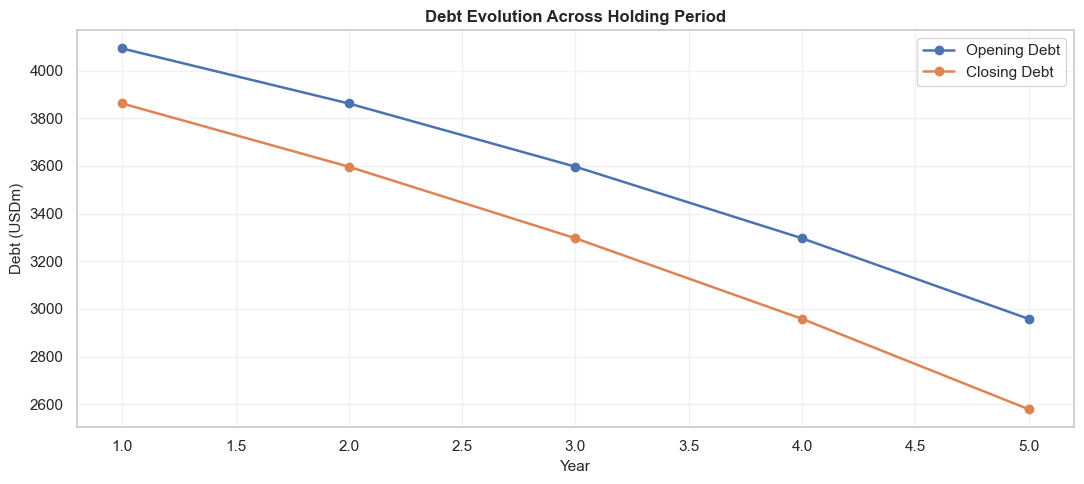

In [30]:
fig, ax = plt.subplots()
ax.plot(debt_schedule["Year"], debt_schedule["OpeningDebt"], marker="o", linewidth=1.8, label="Opening Debt")
ax.plot(debt_schedule["Year"], debt_schedule["ClosingDebt"], marker="o", linewidth=1.8, label="Closing Debt")
ax.set_title("Debt Evolution Across Holding Period")
ax.set_xlabel("Year")
ax.set_ylabel("Debt (USDm)")
ax.legend(frameon=True)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 9. Credit metrics

Financial question: from a lender perspective, is credit quality improving fast enough?

Why it matters: debt investors focus on leverage, coverage, and debt paydown trajectories.

Link: the debt schedule provides the raw data for covenant-style monitoring.


### Compute lender-facing monitoring metrics

We align with drill-style metrics: % senior debt repaid, % total debt repaid, EBITDA / net interest expense, and Net debt / EBITDA.


In [31]:
initial_senior_debt = initial_debt_dict["Term debt A"] + initial_debt_dict["Term debt B"] + initial_debt_dict["Term debt C"]
initial_total_debt = debt_total

credit_metrics = pd.DataFrame({
    "Year": operating_model["Year"],
    "EBITDA": operating_model["EBITDA"],
    "NetInterestExpense": debt_schedule["InterestExpense"],
    "SeniorDebt": debt_schedule["Closing_TDA"] + debt_schedule["Closing_TDB"] + debt_schedule["Closing_TDC"],
    "TotalDebt": debt_schedule["ClosingDebt"],
})

credit_metrics["Cash"] = assumptions["cash_on_balance_sheet"]
credit_metrics["NetDebt"] = credit_metrics["TotalDebt"] - credit_metrics["Cash"]
credit_metrics["PctSeniorDebtRepaid"] = 1 - (credit_metrics["SeniorDebt"] / initial_senior_debt)
credit_metrics["PctTotalDebtRepaid"] = 1 - (credit_metrics["TotalDebt"] / initial_total_debt)
credit_metrics["EBITDA_to_Interest"] = credit_metrics["EBITDA"] / credit_metrics["NetInterestExpense"]
credit_metrics["NetDebt_to_EBITDA"] = credit_metrics["NetDebt"] / credit_metrics["EBITDA"]

credit_metrics


,Year,EBITDA,NetInterestExpense,SeniorDebt,TotalDebt,Cash,NetDebt,PctSeniorDebtRepaid,PctTotalDebtRepaid,EBITDA_to_Interest,NetDebt_to_EBITDA
0,1,875.65,292.39,3277.67,3862.45,16.80,3845.65,0.07,0.06,2.99,4.39
1,2,923.81,278.27,3012.19,3596.97,16.80,3580.17,0.14,0.12,3.32,3.88
2,3,974.62,262.07,2711.66,3296.44,16.80,3279.64,0.23,0.19,3.72,3.37
3,4,1028.22,243.78,2373.25,2958.03,16.80,2941.23,0.32,0.28,4.22,2.86
4,5,1084.78,223.21,1993.92,2578.70,16.80,2561.90,0.43,0.37,4.86,2.36


### Interpretation

- Falling **Net Debt / EBITDA** indicates deleveraging progress and usually better refinancing optionality.
- Rising **EBITDA / Interest** signals stronger debt-servicing capacity.
- Repayment percentages show how much of sponsor value creation comes from balance sheet repair.

From a lender viewpoint, covenant headroom and refinancing risk are dynamic, not static. A model that only reports final-year leverage misses this risk path.


## 10. Exit valuation and equity returns

Financial question: what does the sponsor earn at exit, and which drivers dominate those returns?

Why it matters: MOIC and IRR are central outputs for equity holders.

Link: after reviewing lender metrics, we shift to sponsor value realization.


### Build exit bridge and sponsor cash flow schedule

To stay close to drill logic, we first compute equity value by year at a fixed exit multiple, then apply the selected exit-year assumption for IRR and MOIC.


In [32]:
exit_year = assumptions["holding_period_years"]

exit_profile = pd.DataFrame({
    "Year": operating_model["Year"],
    "EnterpriseValue_onExit": operating_model["EBITDA"] * assumptions["exit_multiple"],
    "NetDebt_onExit": credit_metrics["NetDebt"],
})
exit_profile["EquityValue_onExit"] = exit_profile["EnterpriseValue_onExit"] - exit_profile["NetDebt_onExit"]

exit_ebitda = exit_profile.loc[exit_profile["Year"] == exit_year, "EnterpriseValue_onExit"].iloc[0] / assumptions["exit_multiple"]
exit_ev = exit_profile.loc[exit_profile["Year"] == exit_year, "EnterpriseValue_onExit"].iloc[0]
remaining_net_debt = exit_profile.loc[exit_profile["Year"] == exit_year, "NetDebt_onExit"].iloc[0]
exit_equity_value = exit_profile.loc[exit_profile["Year"] == exit_year, "EquityValue_onExit"].iloc[0]

sponsor_cash_flows = [-sponsor_equity] + [0.0] * (exit_year - 1) + [exit_equity_value]
moic = exit_equity_value / sponsor_equity
irr = npf.irr(sponsor_cash_flows)

exit_summary = pd.DataFrame({
    "Metric": [
        "Exit Year",
        "Exit EBITDA (USDm)",
        "Exit Multiple (x)",
        "Exit Enterprise Value (USDm)",
        "Remaining Net Debt (USDm)",
        "Exit Equity Value (USDm)",
        "Sponsor MOIC (x)",
        "Sponsor IRR",
    ],
    "Value": [
        exit_year,
        exit_ebitda,
        assumptions["exit_multiple"],
        exit_ev,
        remaining_net_debt,
        exit_equity_value,
        moic,
        irr,
    ],
})

cashflow_schedule = pd.DataFrame({
    "YearCount": list(range(0, exit_year + 1)),
    "CashFlows_to_Equity": sponsor_cash_flows,
})

exit_profile, exit_summary, cashflow_schedule


(   Year  EnterpriseValue_onExit  NetDebt_onExit  EquityValue_onExit
 0     1                 6567.38         3845.65             2721.73
 1     2                 6928.58         3580.17             3348.41
 2     3                 7309.65         3279.64             4030.01
 3     4                 7711.68         2941.23             4770.46
 4     5                 8135.83         2561.90             5573.93,
                          Metric   Value
 0                     Exit Year    5.00
 1            Exit EBITDA (USDm) 1084.78
 2             Exit Multiple (x)    7.50
 3  Exit Enterprise Value (USDm) 8135.83
 4     Remaining Net Debt (USDm) 2561.90
 5      Exit Equity Value (USDm) 5573.93
 6              Sponsor MOIC (x)    3.18
 7                   Sponsor IRR    0.26,
    YearCount  CashFlows_to_Equity
 0          0             -1754.33
 1          1                 0.00
 2          2                 0.00
 3          3                 0.00
 4          4                 0.00
 5   

### Sources of LBO equity returns

In this framework, sponsor returns come from three interacting drivers:

- **Deleveraging:** debt repayment increases residual equity claim.
- **EBITDA growth:** stronger operating performance lifts exit EBITDA.
- **Multiple movement:** expansion or contraction in exit valuation multiple changes terminal EV.


## 11. Sensitivity analysis

Financial question: how fragile are returns to plausible changes in growth and exit assumptions?

Why it matters: leverage amplifies both upside and downside, making scenario analysis essential.

Link: base-case returns are informative, but decision quality depends on range analysis.


### Create 2D sensitivity table: exit multiple vs EBITDA growth


In [33]:
exit_multiple_grid = np.arange(6.5, 9.5, 0.5)
growth_grid = np.arange(0.03, 0.09, 0.01)


def run_lbo_case(growth_rate: float, exit_multiple_case: float) -> float:
    years_local = np.arange(1, assumptions["holding_period_years"] + 1)

    rev_local = [entry_revenue * (1 + growth_rate) ** y for y in years_local]
    ebitda_local = [r * assumptions["ebitda_margin"] for r in rev_local]
    dep_local = [r * assumptions["depreciation_pct_revenue"] for r in rev_local]
    ebit_local = [e - d for e, d in zip(ebitda_local, dep_local)]
    taxes_local = [max(x, 0) * assumptions["tax_rate"] for x in ebit_local]
    capex_local = [r * assumptions["capex_pct_revenue"] for r in rev_local]

    nwc_local = [r * assumptions["nwc_pct_revenue"] for r in rev_local]
    d_nwc_local = [nwc_local[0]] + [nwc_local[i] - nwc_local[i - 1] for i in range(1, len(nwc_local))]
    fcf_local = [op_ebit - t + d - c - dn for op_ebit, t, d, c, dn in zip(ebit_local, taxes_local, dep_local, capex_local, d_nwc_local)]

    debt_local = initial_debt_dict.copy()
    mandatory_tda_local = initial_debt_dict["Term debt A"] * assumptions["mandatory_amort_tda_pct"]
    mandatory_tdb_local = initial_debt_dict["Term debt B"] * assumptions["mandatory_amort_tdb_pct"]
    mandatory_tdc_local = initial_debt_dict["Term debt C"] * assumptions["mandatory_amort_tdc_pct"]

    for fcf in fcf_local:
        interest_local = sum(debt_local[t] * tranches.loc[t, "InterestRate"] for t in tranches.index)
        cash_after_interest_local = fcf - interest_local

        mand_tda = min(mandatory_tda_local, debt_local["Term debt A"])
        mand_tdb = min(mandatory_tdb_local, debt_local["Term debt B"])
        mand_tdc = min(mandatory_tdc_local, debt_local["Term debt C"])
        mandatory_total_local = mand_tda + mand_tdb + mand_tdc

        cash_after_mand_local = max(cash_after_interest_local - mandatory_total_local, 0)
        sweep_pool_local = cash_after_mand_local * assumptions["cash_sweep_pct"]

        sweep_tda = min(sweep_pool_local, max(debt_local["Term debt A"] - mand_tda, 0))
        sweep_pool_local -= sweep_tda
        sweep_tdb = min(sweep_pool_local, max(debt_local["Term debt B"] - mand_tdb, 0))
        sweep_pool_local -= sweep_tdb
        sweep_tdc = min(sweep_pool_local, max(debt_local["Term debt C"] - mand_tdc, 0))
        sweep_pool_local -= sweep_tdc

        debt_local["Term debt A"] = max(debt_local["Term debt A"] - mand_tda - sweep_tda, 0)
        debt_local["Term debt B"] = max(debt_local["Term debt B"] - mand_tdb - sweep_tdb, 0)
        debt_local["Term debt C"] = max(debt_local["Term debt C"] - mand_tdc - sweep_tdc, 0)

    closing_debt_local = sum(debt_local.values())
    net_debt_local = closing_debt_local - assumptions["cash_on_balance_sheet"]

    exit_ev_local = ebitda_local[-1] * exit_multiple_case
    exit_equity_local = exit_ev_local - net_debt_local

    cf_local = [-sponsor_equity] + [0.0] * (assumptions["holding_period_years"] - 1) + [exit_equity_local]
    return npf.irr(cf_local)


sensitivity_irr = pd.DataFrame(
    index=[f"{g:.0%}" for g in growth_grid],
    columns=[f"{m:.1f}x" for m in exit_multiple_grid],
    dtype=float,
)

for g in growth_grid:
    for m in exit_multiple_grid:
        sensitivity_irr.loc[f"{g:.0%}", f"{m:.1f}x"] = run_lbo_case(g, m)

sensitivity_irr


,6.5x,7.0x,7.5x,8.0x,8.5x,9.0x
3%,0.15,0.18,0.21,0.23,0.26,0.28
4%,0.17,0.20,0.23,0.25,0.28,0.30
5%,0.20,0.22,0.25,0.27,0.30,0.32
6%,0.22,0.24,0.27,0.29,0.32,0.34
7%,0.24,0.26,0.29,0.31,0.33,0.35
8%,0.26,0.28,0.31,0.33,0.35,0.37


### Heatmap visualization

The heatmap expresses IRR in percentage terms for fast classroom interpretation.


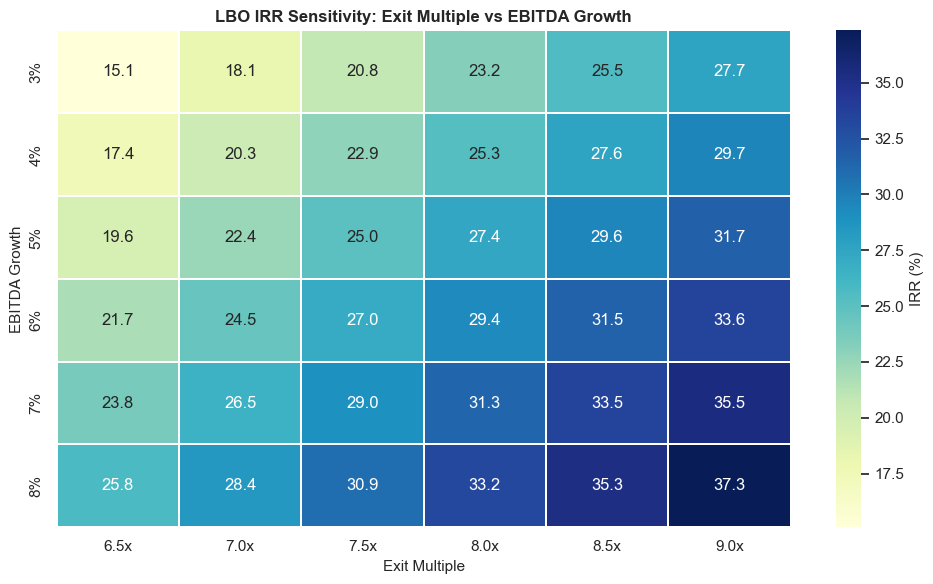

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    sensitivity_irr * 100,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.3,
    cbar_kws={"label": "IRR (%)"},
    ax=ax,
)
ax.set_title("LBO IRR Sensitivity: Exit Multiple vs EBITDA Growth")
ax.set_xlabel("Exit Multiple")
ax.set_ylabel("EBITDA Growth")
plt.tight_layout()
plt.show()


### Interpretation

Returns are highly sensitive to exit assumptions because leverage amplifies both upside and downside. This is why disciplined scenario analysis is necessary before drawing investment conclusions.


## 12. Optional appendix: Pro Forma Balance Sheet Logic and Goodwill

This appendix keeps accounting intuition compact and drill-aligned.

Conceptual bridge:

- Purchase price paid is linked to acquisition cost plus fees.
- Net assets acquired represent identifiable assets minus assumed liabilities (simplified).
- Deal goodwill is the residual premium paid above identifiable net assets.

This is intentionally a concise teaching bridge, not a full accounting build.


### Goodwill bridge and compact pro forma sketch


In [35]:
purchase_price_paid = acquisition_cost + fees
net_assets_acquired = purchase_price_paid * 0.82  # teaching simplification
deal_goodwill = purchase_price_paid - net_assets_acquired

goodwill_bridge = pd.DataFrame({
    "Metric": [
        "Purchase price paid",
        "Net assets acquired (FV, simplified)",
        "Deal goodwill",
    ],
    "USDm": [
        purchase_price_paid,
        net_assets_acquired,
        deal_goodwill,
    ],
})

proforma_sketch = pd.DataFrame({
    "Pro Forma Item": [
        "Identifiable Net Assets",
        "Goodwill",
        "Total Assets",
        "New Debt",
        "New Equity",
        "Balancing Plug",
        "Total Liabilities + Equity",
    ],
    "USDm": [
        net_assets_acquired,
        deal_goodwill,
        net_assets_acquired + deal_goodwill,
        debt_total,
        sponsor_equity,
        (net_assets_acquired + deal_goodwill) - (debt_total + sponsor_equity),
        debt_total + sponsor_equity + ((net_assets_acquired + deal_goodwill) - (debt_total + sponsor_equity)),
    ],
})

goodwill_bridge, proforma_sketch


(                                 Metric    USDm
 0                   Purchase price paid 5550.77
 1  Net assets acquired (FV, simplified) 4551.63
 2                         Deal goodwill  999.14,
                Pro Forma Item    USDm
 0     Identifiable Net Assets 4551.63
 1                    Goodwill  999.14
 2                Total Assets 5550.77
 3                    New Debt 4093.44
 4                  New Equity 1754.33
 5              Balancing Plug -297.00
 6  Total Liabilities + Equity 5550.77)

## 13. Final discussion and interpretation

- What makes an LBO attractive: disciplined entry valuation, resilient cash generation, and credible deleveraging.
- Main value creation channels: debt paydown, EBITDA growth, and exit valuation.
- Where fragility appears: aggressive growth assumptions, weak coverage, and multiple compression.
- Assumptions that matter most: entry multiple, financing mix/cost, operating trajectory, exit year, and exit multiple.
- Theory link: the model operationalizes tax shield logic, trade-off constraints, and agency discipline through debt service pressure.

The practical lesson is that LBO viability is a path-dependent financing-and-operations problem, not just a single IRR output.


## 14. Key takeaways

- LBOs are capital structure decisions with governance implications.
- Sources & Uses anchors the transaction and keeps funding logic explicit.
- Premium and dilution mechanics influence acquisition economics and entry discipline.
- Cash generation and deleveraging determine financing feasibility.
- Lender metrics are essential alongside sponsor MOIC/IRR.
- Returns are highly sensitive to operating and exit assumptions.
- Python offers a transparent translation of Excel drill logic with stronger reproducibility.


## 15. Bridge to Notebook 3

We now move from company-level transaction modeling to market-level strategy design and backtesting. The next notebook applies the same disciplined workflow mindset to trading signals, portfolio returns, and performance evaluation.
